# Etapa 1 - Entendimento e Preparação

Este notebook documenta o processo de entendimento do problema, análise exploratória de dados e construção de um baseline com Regressão Logística.

Dataset utilizado Telco customer churn: IBM dataset.
https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

ML Canvas com os requisitos e a documentação no docs:
[ML Canvas](../docs/ml_canvas.md)

Entendendo os dados 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

In [3]:
dataPath = Path("..") / "data" / "telco_customer_churn_original.xlsx"
df = pd.read_excel(dataPath)

# df.head(5)

## Info e describe

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     6979 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         6984 non-null   str    
 13  Tenure Months      6907 non-null   float64
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,6907.000000,6911.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.377298,64.784062,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.576113,30.076378,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.550000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


                          Coluna  Missing_Count  Missing_Percentage
Churn Reason        Churn Reason           5174               73.46
Tenure Months      Tenure Months            136                1.93
Monthly Charges  Monthly Charges            132                1.87
Senior Citizen    Senior Citizen             64                0.91
Dependents            Dependents             59                0.84


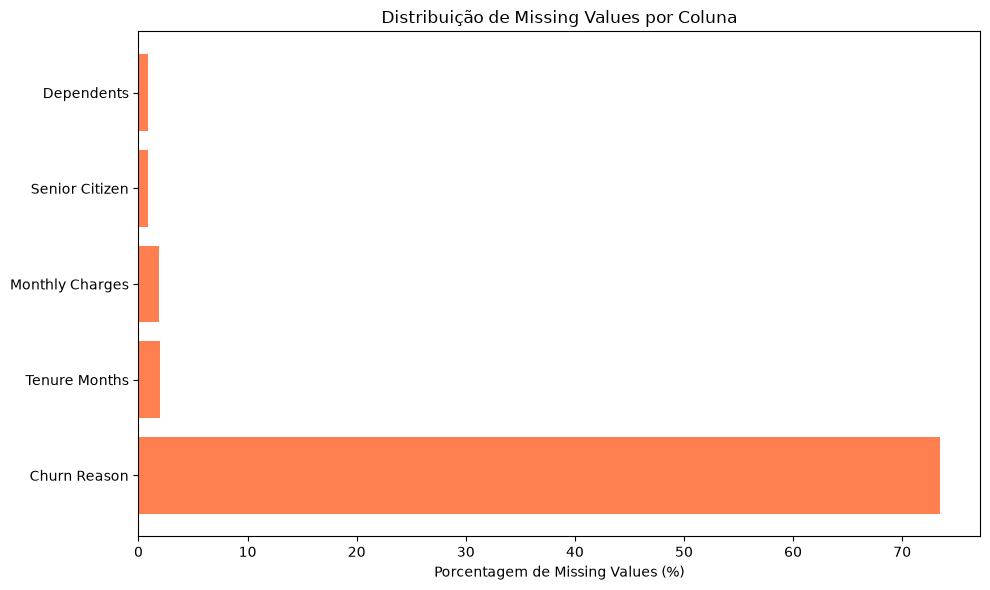

In [5]:
missing_values = pd.DataFrame(
    {
        "Coluna": df.columns,
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2),
    }
)

missing_values = missing_values[missing_values["Missing_Count"] > 0].sort_values(
    by="Missing_Percentage", ascending=False
)

if len(missing_values) > 0:
    print(missing_values)

    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(
        missing_values["Coluna"], missing_values["Missing_Percentage"], color="coral"
    )
    plt.xlabel("Porcentagem de Missing Values (%)")
    plt.title("Distribuição de Missing Values por Coluna")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

### Análise da Variável Target

**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Não Churn (0): 73.46%
Churn (1): 26.54%


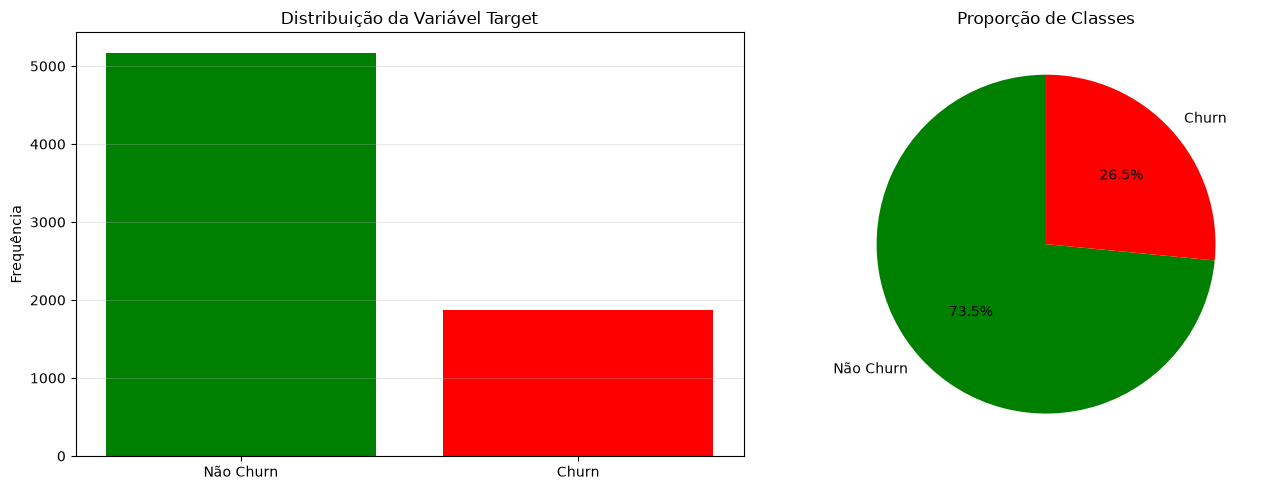


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [6]:
# Renomear variável `Churn Value` para `target`
df.rename(columns={"Churn Value": "target"}, inplace=True)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df["target"].value_counts()
target_percentages = df["target"].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Não Churn" if idx == 0 else "Churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(["Não Churn", "Churn"], target_counts.values, color=["green", "red"])
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição da Variável Target")
axes[0].grid(axis="y", alpha=0.3)

# Gráfico de pizza
axes[1].pie(
    target_counts.values,
    labels=["Não Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["green", "red"],
    startangle=90,
)
axes[1].set_title("Proporção de Classes")

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print(
        "⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight."
    )
else:
    print("✓ Dataset razoavelmente balanceado.")

### Análise de Outliers

**Objetivo:** Identificar valores extremos que podem ser erros de medição ou casos especiais

**Métodos utilizados:**
- **Z-Score**: Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização**: Boxplots para identificação visual

C:\Users\Alves\AppData\Local\Temp\ipykernel_23732\662581340.py:16: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  col_zscore = np.abs(stats.zscore(df[col].dropna()))


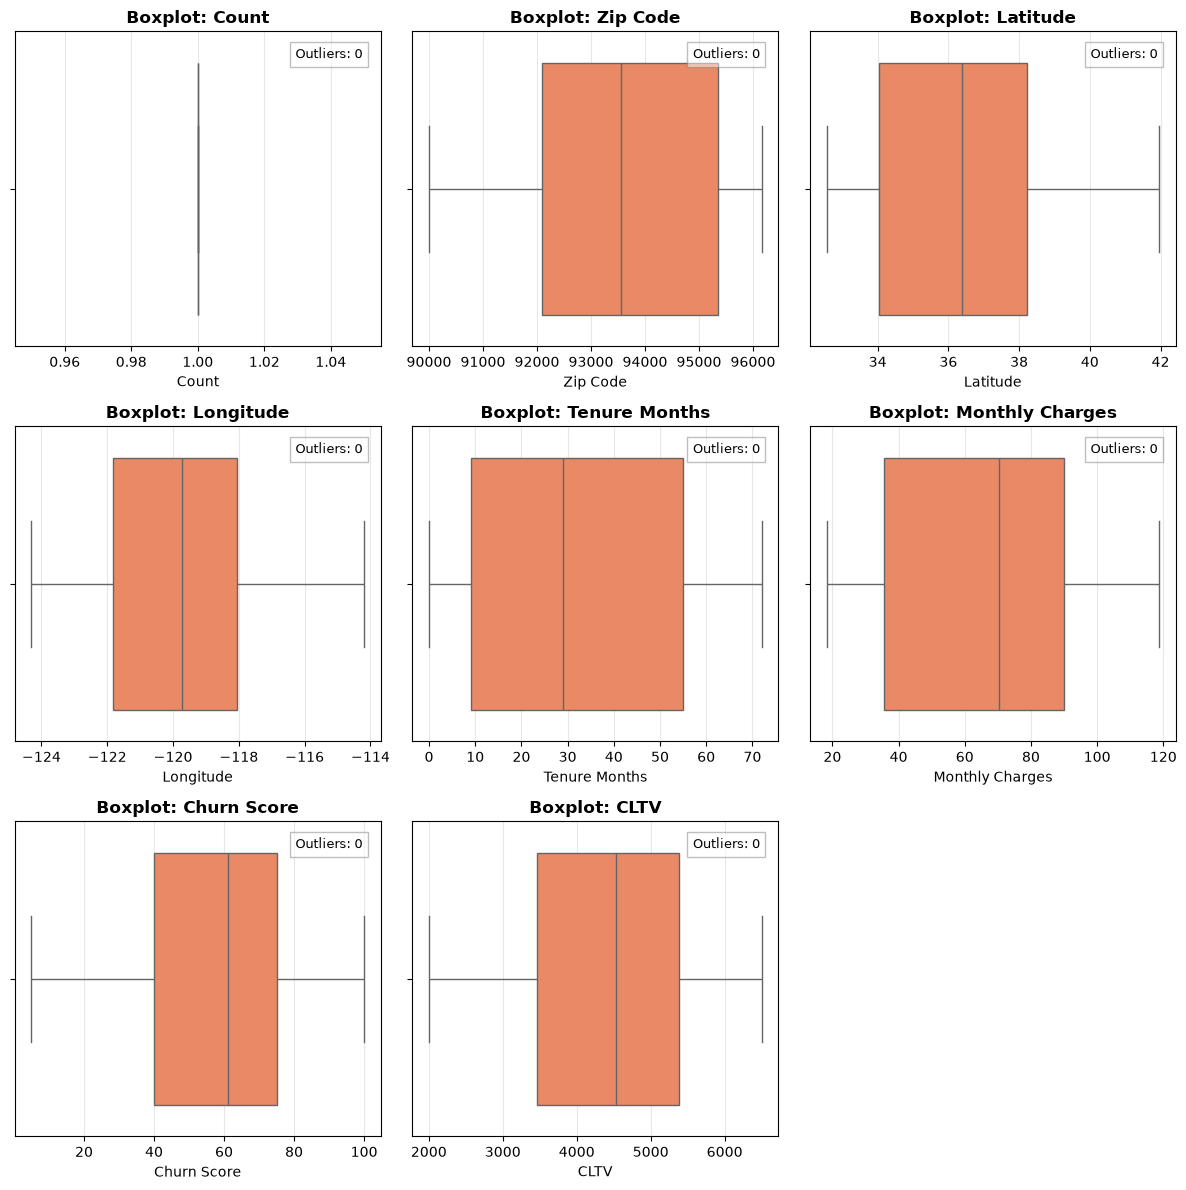

In [7]:
# Colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(["target"])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color="coral")
    axes[idx].set_title(f"Boxplot: {col}", fontweight="bold")
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis="x", alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(
        0.95,
        0.95,
        f"Outliers: {outlier_count}",
        transform=axes[idx].transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.5, edgecolor="gray"),
    )

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Análise de Anomalias e Valores Inválidos

In [8]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

# Verificações de consistência baseadas em conhecimento de domínio
anomalies = []

# 1. Gênero (deve estar entre 'Male' e 'Female' )
valid_genders = ["Male", "Female"]
bad_genders = df[~df["Gender"].isin(valid_genders)]["Gender"].unique()

if len(bad_genders) > 0:
    anomalies.append(f"Gênero inválido detectado: {list(bad_genders)}")


# 2. Internet Services validos
valid_internet_services = ["No", "DSL", "Fiber optic", "Cable"]
bad_internet_services = df[~df["Internet Service"].isin(valid_internet_services)][
    "Internet Service"
].unique()

if len(bad_internet_services) > 0:
    anomalies.append(
        f"Serviço de internet inválido detectado: {list(bad_internet_services)}"
    )


# 3. Contracts validos
valid_contracts = ["Month-to-month", "One year", "Two year"]
bad_contracts = df[~df["Contract"].isin(valid_contracts)]["Contract"].unique()

if len(bad_contracts) > 0:
    anomalies.append(f"Contrato inválido detectado: {list(bad_contracts)}")


# 4. Payment Methods validos
valid_payment_methods = [
    "Mailed check",
    "Electronic check",
    "Bank transfer (automatic)",
    "Credit card (automatic)",
]
bad_payment_methods = df[~df["Payment Method"].isin(valid_payment_methods)][
    "Payment Method"
].unique()

if len(bad_payment_methods) > 0:
    anomalies.append(
        f"Forma de pagamento inválida detectada: {list(bad_payment_methods)}"
    )


# 5. Variáveis categóricas com valores fora do esperado
categorical_checks = {
    "Senior Citizen": ["Yes", "No"],
    "Partner": ["Yes", "No"],
    "Dependents": ["Yes", "No"],
    "Phone Service": ["Yes", "No"],
    "Multiple Lines": ["Yes", "No", "No phone service"],
    "Online Security": ["Yes", "No", "No internet service"],
    "Online Backup": ["Yes", "No", "No internet service"],
    "Device Protection": ["Yes", "No", "No internet service"],
    "Tech Support": ["Yes", "No", "No internet service"],
    "Streaming TV": ["Yes", "No", "No internet service"],
    "Streaming Movies": ["Yes", "No", "No internet service"],
    "Paperless Billing": ["Yes", "No"],
}

for col, valid_values in categorical_checks.items():
    if col in df.columns:
        invalid = df[~df[col].isin(valid_values) & df[col].notna()]
        if len(invalid) > 0:
            anomalies.append(f"{col}: {len(invalid)} valores inválidos")
            print(
                f"⚠️ {col}: {len(invalid)} valores fora do domínio "
                f"esperado {valid_values}"
            )

if len(anomalies) == 0:
    print("✓ Nenhuma anomalia óbvia detectada nas validações de domínio!")
else:
    print(f"\n📊 Total de tipos de anomalias detectadas: {len(anomalies)}")
    print(anomalies)

# Verificar duplicados
duplicates = df.duplicated().sum()
print("\n=== DUPLICADOS ===")
print(f"Registros duplicados: {duplicates}")
if duplicates > 0:
    print("⚠️ Considere remover ou investigar registros duplicados")

=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

✓ Nenhuma anomalia óbvia detectada nas validações de domínio!

=== DUPLICADOS ===
Registros duplicados: 0


### Análise de Distribuições

**Objetivo:** Entender a distribuição das variáveis numéricas e identificar assimetrias Análise de distribuições

=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

         Coluna  Skewness  Kurtosis Interpretação
          Count     0.000     0.000        Normal
       Zip Code    -0.251    -1.154        Normal
       Latitude     0.304    -1.136        Normal
      Longitude    -0.041    -1.136        Normal
  Tenure Months     0.240    -1.388        Normal
Monthly Charges    -0.222    -1.257        Normal
    Churn Score    -0.090    -1.006        Normal
           CLTV    -0.312    -0.934        Normal


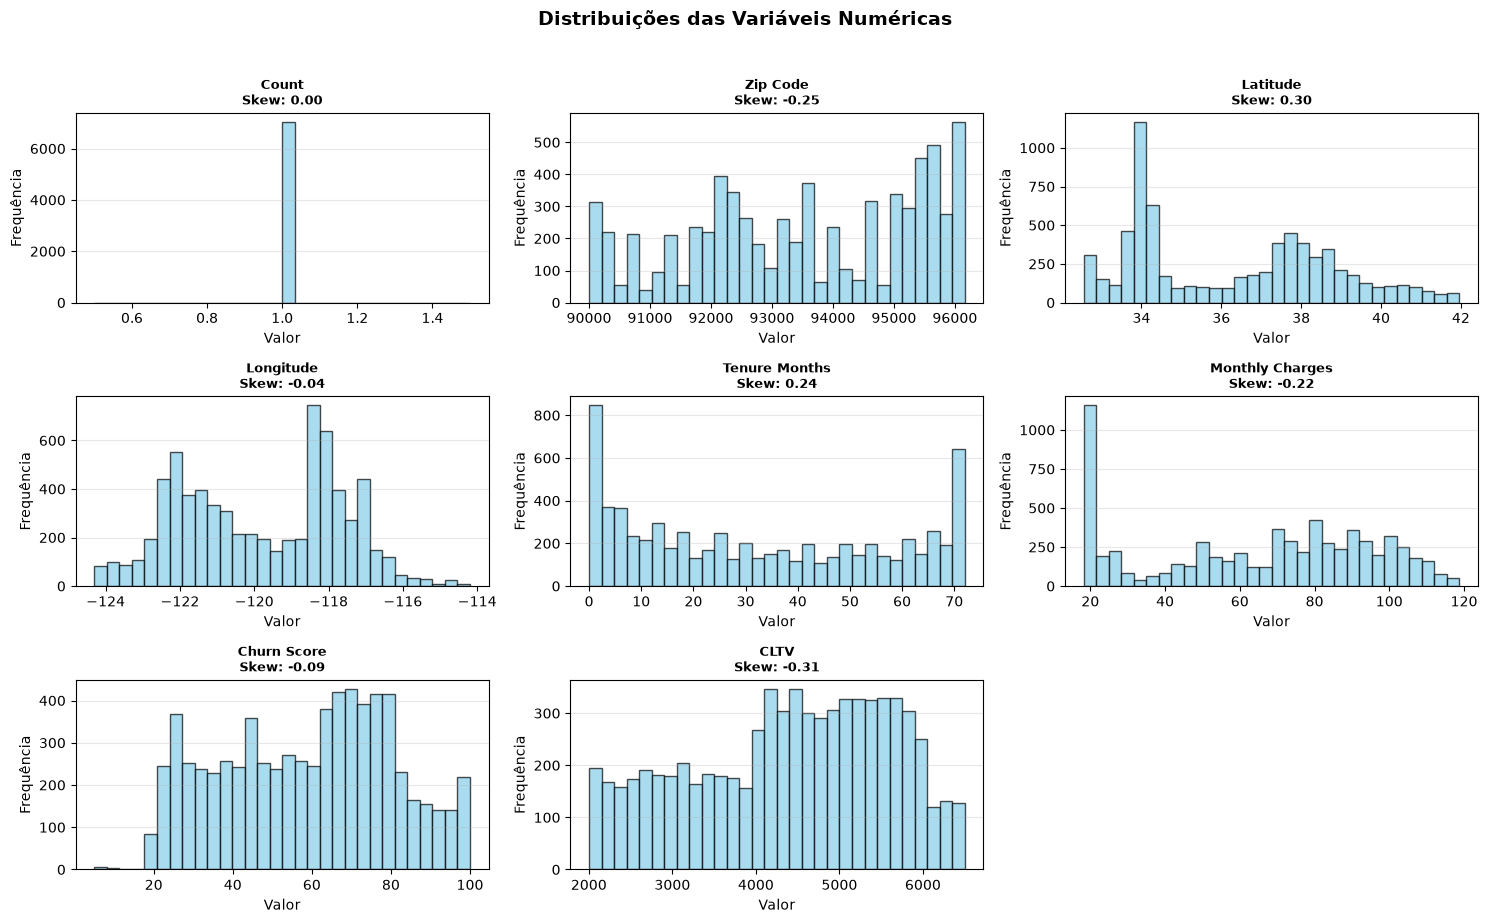

In [9]:
# Análise de distribuições (skewness e kurtosis)
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")
distribution_stats = []

for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()

    distribution_stats.append(
        {
            "Coluna": col,
            "Skewness": round(skewness, 3),
            "Kurtosis": round(kurtosis, 3),
            "Interpretação": (
                "Normal"
                if abs(skewness) < 0.5
                else (
                    "Assimétrica à direita"
                    if skewness > 0
                    else "Assimétrica à esquerda"
                )
            ),
        }
    )

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições conforme o número de colunas
n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))

axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(
            df[col].dropna(), bins=30, color="skyblue", edgecolor="black", alpha=0.7
        )
        axes[idx].set_title(
            f"{col}\nSkew: {df[col].skew():.2f}", fontsize=9, fontweight="bold"
        )
        axes[idx].set_xlabel("Valor")
        axes[idx].set_ylabel("Frequência")
        axes[idx].grid(axis="y", alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    try:
        fig.delaxes(axes[idx])
    except Exception:
        pass

plt.suptitle(
    "Distribuições das Variáveis Numéricas", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

### Análise de Correlações

**Objetivo:** Identificar relações entre variáveis e detectar multicolinearidade

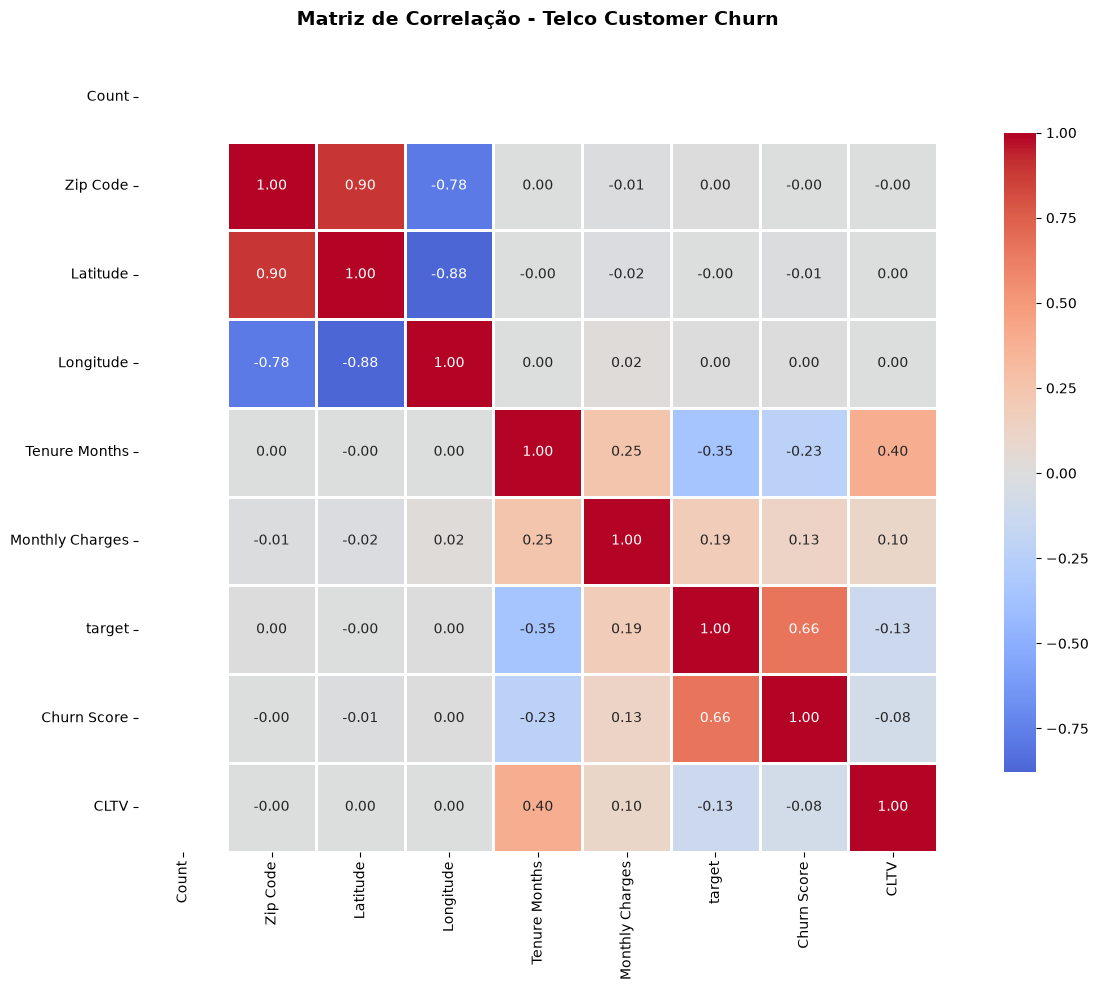

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target             1.000000
Churn Score        0.664897
Monthly Charges    0.193175
Longitude          0.004594
Zip Code           0.003346
Latitude          -0.003384
CLTV              -0.127463
Tenure Months     -0.354732
Count                   NaN
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

Feature 1 Feature 2  Correlação
 Zip Code  Latitude       0.896
 Zip Code Longitude      -0.784
 Latitude Longitude      -0.877

⚠️ Alta correlação entre features pode causar multicolinearidade!


In [10]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_numeric,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Matriz de Correlação - Telco Customer Churn",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")

if "target" in corr_numeric.columns:
    target_corr = corr_numeric["target"].sort_values(ascending=False)
    print(target_corr)
else:
    print(
        "Coluna 'target' não encontrada em correlações. "
        "Verifique o rename da target."
    )

# Identificar pares de features com alta correlação
# (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
cols = corr_numeric.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if cols[i] == "target" or cols[j] == "target":
            continue

        val = corr_numeric.iloc[i, j]

        if pd.notna(val) and abs(val) > 0.7:
            high_corr_pairs.append(
                {
                    "Feature 1": cols[i],
                    "Feature 2": cols[j],
                    "Correlação": round(val, 3),
                }
            )

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
        by="Correlação", ascending=False
    )

    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar " "multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features " "(excluindo target)")

Quantidade de valores distintos por coluna:
Latitude     1652
Lat Long     1652
Zip Code     1652
Longitude    1651
City         1129
Country         1
State           1
dtype: int64


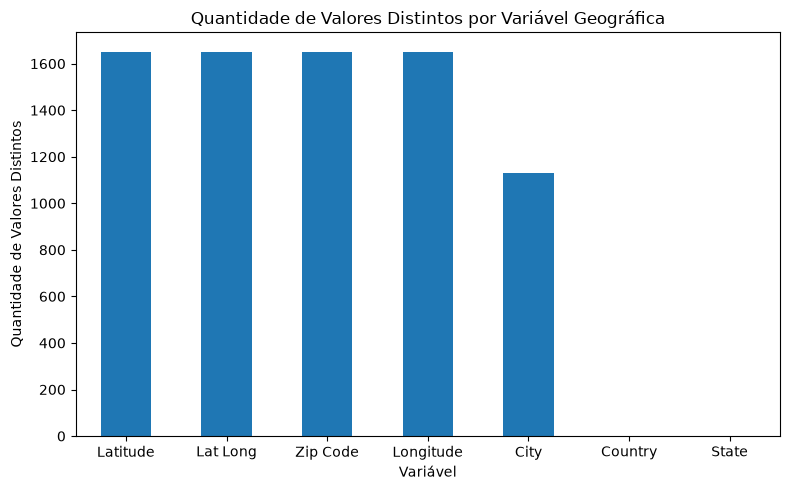

In [11]:
# Colunas geográficas que serão analisadas
columns = ["City", "State", "Country", "Zip Code", "Lat Long", "Latitude", "Longitude"]

# Conta a quantidade de valores distintos em cada coluna
distinct_counts = df[columns].nunique().sort_values(ascending=False)

# Tabela
print("Quantidade de valores distintos por coluna:")
print(distinct_counts)

# Gráfico
plt.figure(figsize=(8, 5))
distinct_counts.plot(kind="bar")
plt.title("Quantidade de Valores Distintos por Variável Geográfica")
plt.xlabel("Variável")
plt.ylabel("Quantidade de Valores Distintos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Preparação dos dados

### Dropar colunas que não serão utilizadas

In [12]:
# Copiar o dataframe original para preservar os dados
df_clean = df.copy()

# Remove colunas geográficas com alta cardinalidade, colunas irrelevantes para o
# modelo e colunas que causam vazamento de dado (data leakage):
# - `Churn Label` é idêntica ao `target` (mesma informação em texto)
# - `Churn Reason` só é preenchida após o cliente cancelar (info pós-evento,
#   indisponível no momento em que a previsão precisa ser feita)
df_clean.drop(
    columns=[
        "CustomerID",
        "Count",
        "City",
        "State",
        "Country",
        "Zip Code",
        "Lat Long",
        "Latitude",
        "Longitude",
        "CLTV",
        "Churn Score",
        "Churn Label",
        "Churn Reason",
    ],
    inplace=True,
)

### Correção de tipo: Total Charges

**Objetivo:** `Total Charges` foi lida como texto porque 11 registros têm valor em branco.
Todos correspondem a clientes com `Tenure Months == 0` (ainda não foram cobrados), então o
valor correto é `0`, não uma imputação estatística como mediana/moda.

In [13]:
# Total Charges veio como texto; converte pra numérico e força NaN nos brancos
total_charges_numeric = pd.to_numeric(df_clean["Total Charges"], errors="coerce")
invalid_mask = total_charges_numeric.isna()

print(f"Registros com Total Charges inválido: {invalid_mask.sum()}")
print(df_clean.loc[invalid_mask, ["Tenure Months", "Total Charges"]])

assert (
    df_clean.loc[invalid_mask, "Tenure Months"].eq(0).all()
), "Existem valores inválidos de Total Charges fora do caso Tenure Months == 0"

# Todos os casos inválidos são clientes novos (tenure = 0) -> cobrança total ainda é 0
df_clean["Total Charges"] = total_charges_numeric.fillna(0)
print("✓ Total Charges convertido para numérico e corrigido.")

Registros com Total Charges inválido: 11
      Tenure Months Total Charges
2234            0.0              
2438            0.0              
2568            0.0              
2667            0.0              
2856            0.0              
4331            0.0              
4687            0.0              
5104            0.0              
5719            0.0              
6772            0.0              
6840            0.0              
✓ Total Charges convertido para numérico e corrigido.


### Tratamento de missing values

In [14]:
# Divisão prévia em treino e teste para evitar data leakage:
X_raw = df_clean.drop(columns=["target"])
y_raw = df_clean["target"]
X_train_raw, X_test_raw, _, _ = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Imputação para variáveis numéricas: mediana calculada SOMENTE no treino
num_missing = ["Tenure Months", "Monthly Charges"]
for col in num_missing:
    if col in X_train_raw.columns:
        median = X_train_raw[col].median()
        df_clean[col] = df_clean[col].fillna(median)
        print(f"{col}: imputado com mediana do treino ({median:.2f})")


# Imputação para variáveis categóricas: moda calculada SOMENTE no treino
cat_missing = ["Senior Citizen", "Dependents"]
for col in cat_missing:
    if col in X_train_raw.columns:
        mode = X_train_raw[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode)
        print(f"{col}: imputado com moda do treino ('{mode}')")

print("✓ Tratamento de missing values concluído!")
print(f"Shape após imputação: {df_clean.shape}")
print("Valores ausentes restantes por coluna:")
print(df_clean.isnull().sum())

Tenure Months: imputado com mediana do treino (29.00)
Monthly Charges: imputado com mediana do treino (70.20)
Senior Citizen: imputado com moda do treino ('No')
Dependents: imputado com moda do treino ('No')
✓ Tratamento de missing values concluído!
Shape após imputação: (7043, 20)
Valores ausentes restantes por coluna:
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
target               0
dtype: int64


### Aplicar one-hot-encoding em colunas de categorização

In [15]:
# One-hot encoding de todas as variáveis categóricas restantes
# (as demais colunas de df_clean já são numéricas: Tenure Months, Monthly Charges,
# Total Charges e target)
numeric_feature_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]
categorical_cols = [
    c for c in df_clean.columns if c not in numeric_feature_cols + ["target"]
]
print(f"Colunas categóricas codificadas ({len(categorical_cols)}): {categorical_cols}")

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"\nShape após one-hot encoding: {df_encoded.shape}")
df_encoded.head()

Colunas categóricas codificadas (16): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Shape após one-hot encoding: (7043, 31)


,Tenure Months,Monthly Charges,Total Charges,target,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2.0,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2.0,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8.0,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28.0,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49.0,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


## Definição de métricas

**Métrica de negócio:** redução da taxa de churn (Churn Rate) — detalhada no
[ML Canvas](../docs/ml_canvas.md).

**Métrica técnica:** a base é desbalanceada (~26,5% de churn), então acurácia isoladamente
é enganosa — um modelo que sempre prevê "não churn" já acertaria ~73,5% sem nenhum valor
preditivo. Serão usadas:

- **F1-score** (classe positiva = churn): equilibra precisão e recall — relevante porque
  tanto o falso negativo (perder um cliente que iria cancelar) quanto o falso positivo
  (gastar esforço de retenção à toa) têm custo para o negócio.
- **AUC-ROC**: mede a capacidade do modelo de ranquear clientes por risco, independente do
  limiar de decisão escolhido — útil já que a equipe de retenção provavelmente vai priorizar
  os N clientes de maior risco, não usar um corte fixo de 0.5.

## Baseline: Regressão Logística

Modelo baseline exigido pela Etapa 1, treinado sobre os dados limpos e codificados
(`df_encoded`), com seed fixa para reprodutibilidade.

In [16]:
RANDOM_STATE = 42

X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# StandardScaler evita problema de convergência do solver por causa da escala das
# variáveis numéricas (ex.: Total Charges na casa dos milhares vs. dummies 0/1)
baseline_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=== BASELINE: REGRESSÃO LOGÍSTICA ===\n")
print(f"F1-score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Não Churn", "Churn"]))

print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred))

# Referência: classificador ingênuo que sempre prevê a classe majoritária
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_f1 = f1_score(y_test, dummy.predict(X_test))
print(f"\nF1-score do baseline ingênuo (sempre 'não churn'): {dummy_f1:.4f}")
print(f"Ganho do modelo sobre o baseline ingênuo: +{f1 - dummy_f1:.4f} em F1-score")

=== BASELINE: REGRESSÃO LOGÍSTICA ===

F1-score: 0.6099
AUC-ROC: 0.8484

              precision    recall  f1-score   support

   Não Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Matriz de confusão:
[[919 116]
 [159 215]]

F1-score do baseline ingênuo (sempre 'não churn'): 0.0000
Ganho do modelo sobre o baseline ingênuo: +0.6099 em F1-score


# Etapa 2 - Modelagem e Avaliação

Treinamento e comparação de um modelo baseado em árvores (Random Forest) e uma
rede neural simples (MLPClassifier) contra o baseline da Etapa 1, com
validação cruzada para garantir a robustez da comparação.

## Validação cruzada

A comparação entre os modelos é feita com validação cruzada estratificada
(5 folds) **apenas sobre `X_train`**, mantendo `X_test` como holdout final
intocado para a confirmação do modelo campeão.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_results = []


def evaluate_with_cv(model, name):
    scores = cross_validate(
        model, X_train, y_train, cv=cv, scoring=["f1", "roc_auc"], n_jobs=-1
    )
    f1_mean, f1_std = scores["test_f1"].mean(), scores["test_f1"].std()
    auc_mean, auc_std = scores["test_roc_auc"].mean(), scores["test_roc_auc"].std()

    print(f"=== {name} (validação cruzada, 5 folds) ===")
    print(f"F1-score: {f1_mean:.4f} (+/- {f1_std:.4f})")
    print(f"AUC-ROC: {auc_mean:.4f} (+/- {auc_std:.4f})\n")

    model_results.append(
        {
            "modelo": name,
            "f1_mean": f1_mean,
            "f1_std": f1_std,
            "auc_mean": auc_mean,
            "auc_std": auc_std,
        }
    )

## Modelo Linear: Regressão Logística (baseline)

Mesma configuração da Etapa 1, agora avaliada por validação cruzada.

In [18]:
logreg_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
evaluate_with_cv(logreg_model, "Regressão Logística (baseline)")

=== Regressão Logística (baseline) (validação cruzada, 5 folds) ===
F1-score: 0.6159 (+/- 0.0307)
AUC-ROC: 0.8582 (+/- 0.0119)



## Modelo baseado em Árvores: Random Forest

Ensemble de árvores de decisão; não precisa de escala das variáveis
numéricas, mas captura relações não-lineares que a Regressão Logística não
consegue.

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
)
evaluate_with_cv(rf_model, "Random Forest")

=== Random Forest (validação cruzada, 5 folds) ===
F1-score: 0.5785 (+/- 0.0298)
AUC-ROC: 0.8410 (+/- 0.0112)



## Rede Neural simples: MLPClassifier

Uma camada oculta pequena (16 neurônios) — suficiente para um problema
tabular deste porte sem overfitar. Assim como a Regressão Logística, é
sensível à escala das variáveis, por isso o `StandardScaler`.

In [20]:
mlp_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            MLPClassifier(
                hidden_layer_sizes=(16,),
                max_iter=500,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
evaluate_with_cv(mlp_model, "MLP (Rede Neural)")

=== MLP (Rede Neural) (validação cruzada, 5 folds) ===
F1-score: 0.5930 (+/- 0.0205)
AUC-ROC: 0.8461 (+/- 0.0067)



## Comparação dos modelos

In [21]:
comparison_df = pd.DataFrame(model_results).sort_values(by="f1_mean", ascending=False)
comparison_df

,modelo,f1_mean,f1_std,auc_mean,auc_std
0,Regressão Logística (baseline),0.615929,0.030708,0.858181,0.011894
2,MLP (Rede Neural),0.592961,0.020483,0.846104,0.006694
1,Random Forest,0.578476,0.029755,0.841025,0.011236


## Escolha do modelo campeão

O critério de desempate é o **F1-score médio na validação cruzada** (métrica
técnica principal, definida acima). O modelo escolhido é então re-treinado em
todo o `X_train` e confirmado uma única vez no holdout (`X_test`), que não foi
usado em nenhuma etapa de comparação.

In [22]:
candidate_models = {
    "Regressão Logística (baseline)": logreg_model,
    "Random Forest": rf_model,
    "MLP (Rede Neural)": mlp_model,
}

champion_name = comparison_df.iloc[0]["modelo"]
champion_model = candidate_models[champion_name]

print(f"Modelo campeão: {champion_name}\n")

champion_model.fit(X_train, y_train)
y_pred = champion_model.predict(X_test)
y_proba = champion_model.predict_proba(X_test)[:, 1]

f1_holdout = f1_score(y_test, y_pred)
auc_holdout = roc_auc_score(y_test, y_proba)

print("=== CONFIRMAÇÃO NO HOLDOUT (X_test) ===\n")
print(f"F1-score: {f1_holdout:.4f}")
print(f"AUC-ROC: {auc_holdout:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Não Churn", "Churn"]))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred))

# Nota: este modelo usa o encoding manual (pd.get_dummies) deste notebook, que
# NÃO é compatível com o pipeline de produção em src/preprocessing.py (usado
# pela API). O artefato de produção em models/champion_model.joblib é gerado
# por `python -m src.train`, que já treina o mesmo tipo de modelo campeão
# (ver src/train.py) sobre o ColumnTransformer compartilhado com a API.
print(
    f"\nConclusão: o modelo campeão é {champion_name}. "
    "Artefato de produção gerado por `python -m src.train`."
)

Modelo campeão: Regressão Logística (baseline)

=== CONFIRMAÇÃO NO HOLDOUT (X_test) ===

F1-score: 0.6099
AUC-ROC: 0.8484

              precision    recall  f1-score   support

   Não Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Matriz de confusão:
[[919 116]
 [159 215]]

Conclusão: o modelo campeão é Regressão Logística (baseline). Artefato de produção gerado por `python -m src.train`.
